In [251]:
import numpy as np
import matplotlib.pyplot as plt

In [252]:
def signal(t):
    return (np.sin(2 * np.pi * 5 * t)
            + np.sin(2 * np.pi * 50 * t)
            + np.sin(2 * np.pi * 100 * t))

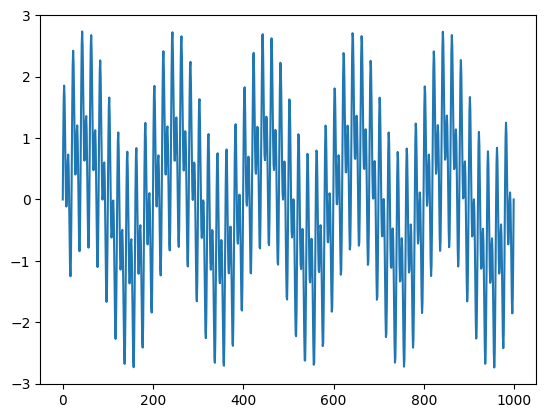

In [253]:
t = np.linspace(0, 1, 1000)
x = signal(t)
plt.plot(x)

In [254]:
fs = 1000
fc = 50 / fs
N = 20
M = N - 1

In [255]:
def DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X

def ideal_impulse_response():
    hd = np.zeros(N)
    for n in range(N):
        if n == M // 2:
            hd[n] = 2 * fc
        else:
            hd[n] = (np.sin(2 * np.pi * fc * (n - M / 2)) / (np.pi * (n - M / 2)))
    return hd

def hamming_window():
    w = np.zeros(N)
    for n in range(N):
        w[n] = 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    return w

def impulse_response(hd, w):
    return hd * w

def convolution(x, h):
    N = len(x)
    M = len(h)
    y = np.zeros(N + M - 1)
    for n in range(N + M - 1):
        for k in range(N):
            if 0 <= n - k < M:
                y[n] +=  x[k] * h[n - k]
    return y

def plot(x, y, title):
    plt.plot(x, y)
    plt.title(str)
    plt.grid(True)

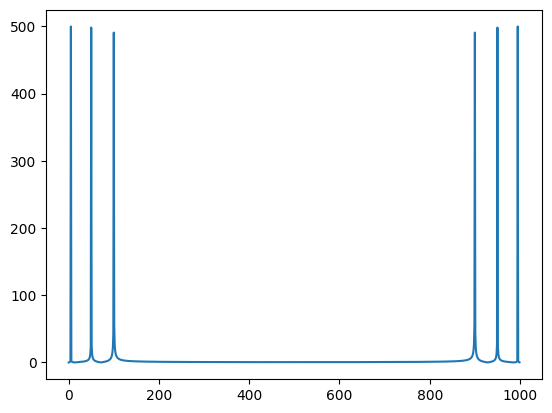

In [256]:
X = DFT(x)
magnitude = np.abs(X)
plt.plot(magnitude)

In [257]:
hd = ideal_impulse_response()
w = hamming_window()
h = impulse_response(hd, w)
y = convolution(x, h)

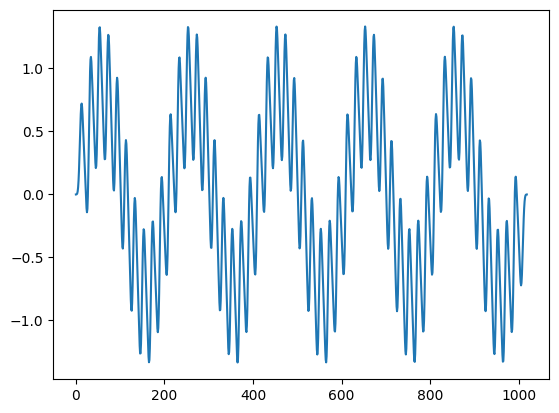

In [258]:
plt.plot(y)

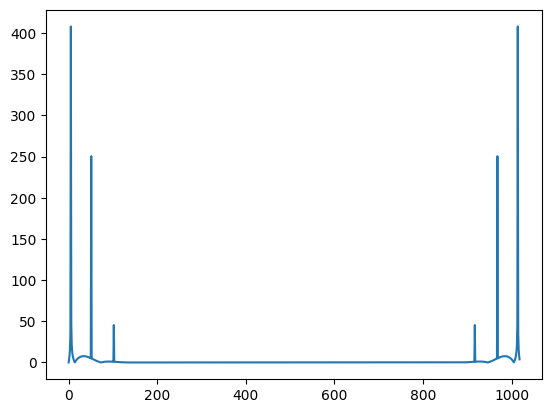

In [259]:
filter_output_dft = DFT(y)
magnitude_after_filter = np.abs(filter_output_dft)
plt.plot(magnitude_after_filter)